In [62]:
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

In [63]:
path = "../data/melspecs/00/"
mel1 = np.load(f"{path}7400.npy")
mel2 =  np.load(f"{path}12100.npy")
print(mel1.shape)
print(mel2.shape)


(96, 6845)
(96, 9296)


<Figure size 1000x800 with 0 Axes>

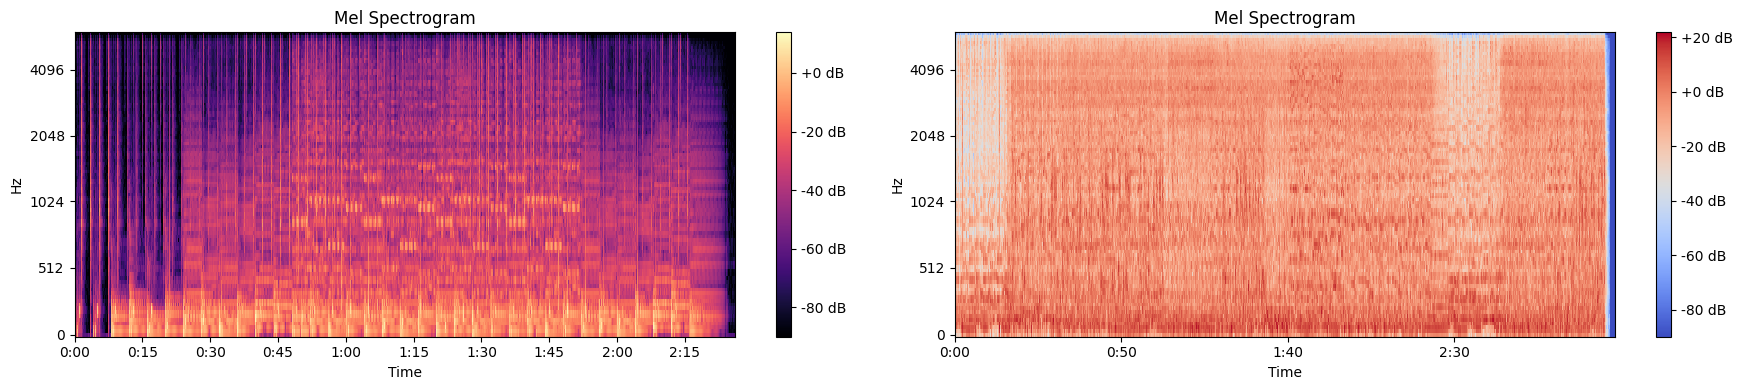

In [64]:
# Displaying the Mel Spectrograms Downloaded

# sampleRate = 12000 and hopSize=256 from the dataset
plt.figure(figsize=(10, 8))
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, mel, title in zip(axes, [mel1, mel2], ["Track 1", "Track 2"]):
    img = librosa.display.specshow(mel, x_axis='time', y_axis='mel', sr=12000, hop_length=256, ax=ax)                                       
    fig.colorbar(img, ax=ax, format='%+2.0f dB')                                                                                             
    ax.set_title("Mel Spectrogram")                                                                                                          
plt.tight_layout()                                                                                                                       
plt.show()                                                                                                                               

In [85]:
## DF WITH ONLY MOOD and THEME

import pandas as pd                                                                                                                      

# MOOD/THEME TSV                                                                                                                             
rows = []
with open('../data/metadata/autotagging_moodtheme.tsv') as f:                                                                            
    next(f)  # skip header
    for line in f:
        parts = line.rstrip('\n').split('\t')                                                                                            
        rows.append({
            'TRACK_ID': parts[0],                                                                                                        
            'ARTIST_ID': parts[1],
            'ALBUM_ID': parts[2],                                                                                                        
            'PATH': parts[3],
            'DURATION': float(parts[4]),                                                                                                 
            'TAGS_MOOD': parts[5:],  # all remaining fields are tags
        })    

df = pd.DataFrame(rows)
df.head()  

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[mood/theme---background]
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[mood/theme---background]
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[mood/theme---background]
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic]


TAGS_MOOD
mood/theme---happy        1657
mood/theme---film         1502
mood/theme---energetic    1357
mood/theme---relaxing     1350
mood/theme---emotional    1271
Name: count, dtype: int64


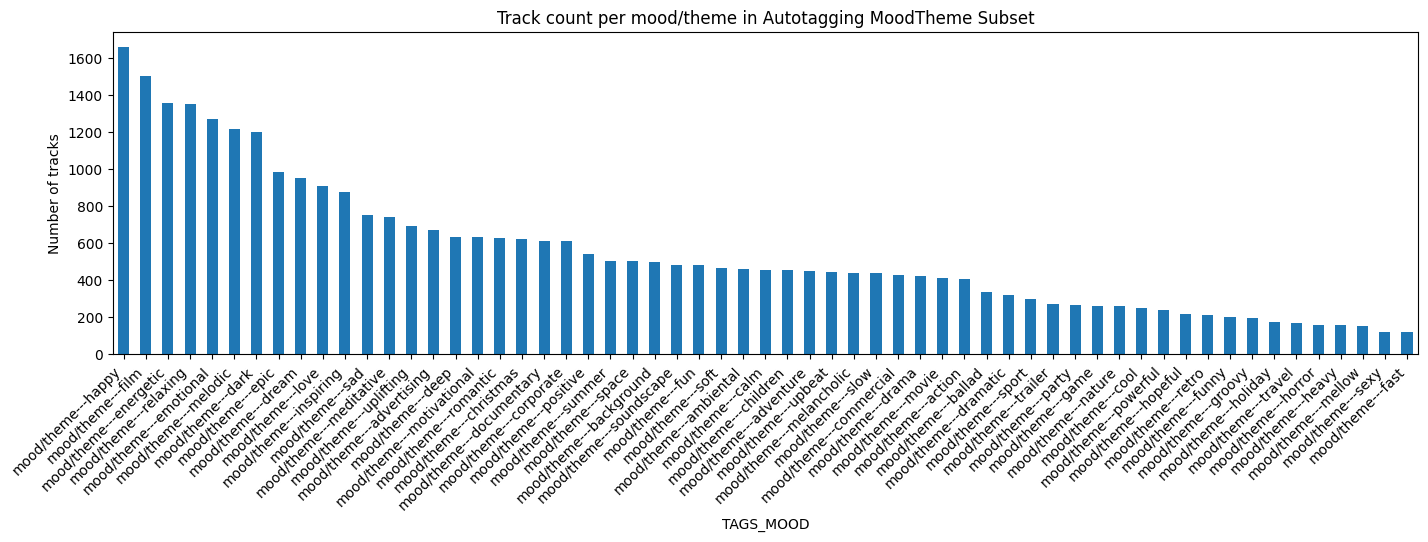

In [89]:
# Distribution of Mood/Theme (Num Tracks vs Tags)

exploded_tags = df.explode('TAGS_MOOD')
tag_counts = exploded_tags['TAGS_MOOD'].value_counts()
print(tag_counts.head())

plt.figure(figsize=(14,6))
tag_counts.plot(kind='bar')
plt.title("Track count per mood/theme in Autotagging MoodTheme Subset")
plt.ylabel("Number of tracks")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

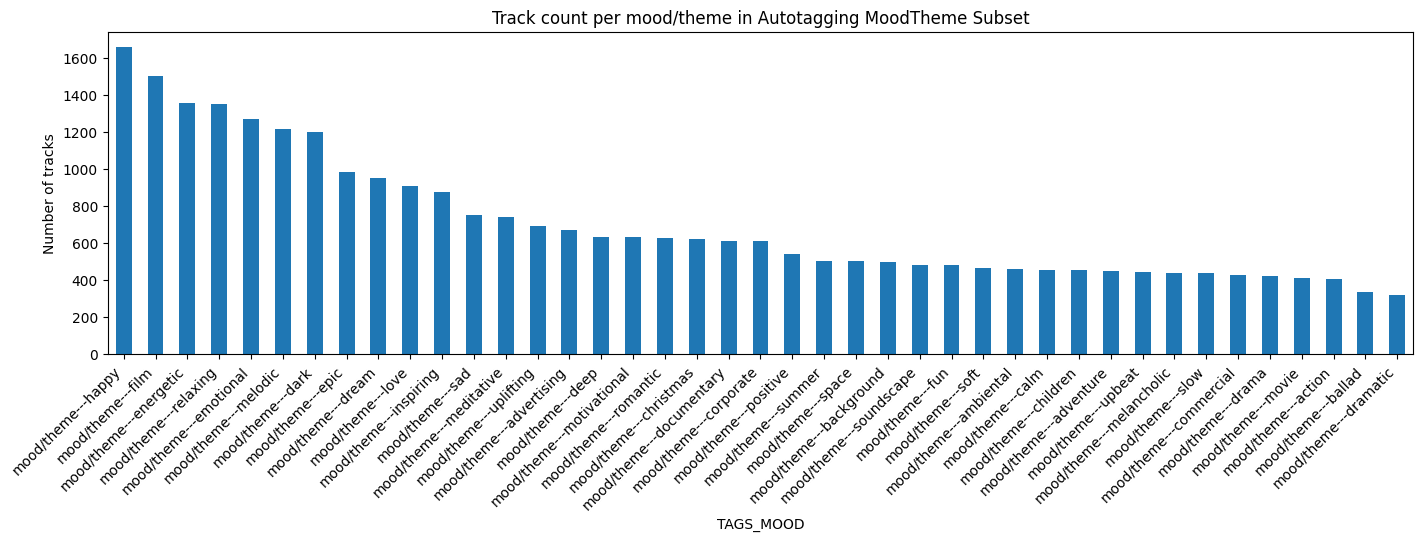

In [90]:
# Filtered Distribution of Mood/Theme (Num Tracks vs Tags where num tracks > 300)

filtered_tag_counts = tag_counts[tag_counts > 300]
plt.figure(figsize=(14,6))
filtered_tag_counts.plot(kind='bar')
plt.title("Track count per mood/theme in Autotagging MoodTheme Subset")
plt.ylabel("Number of tracks")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

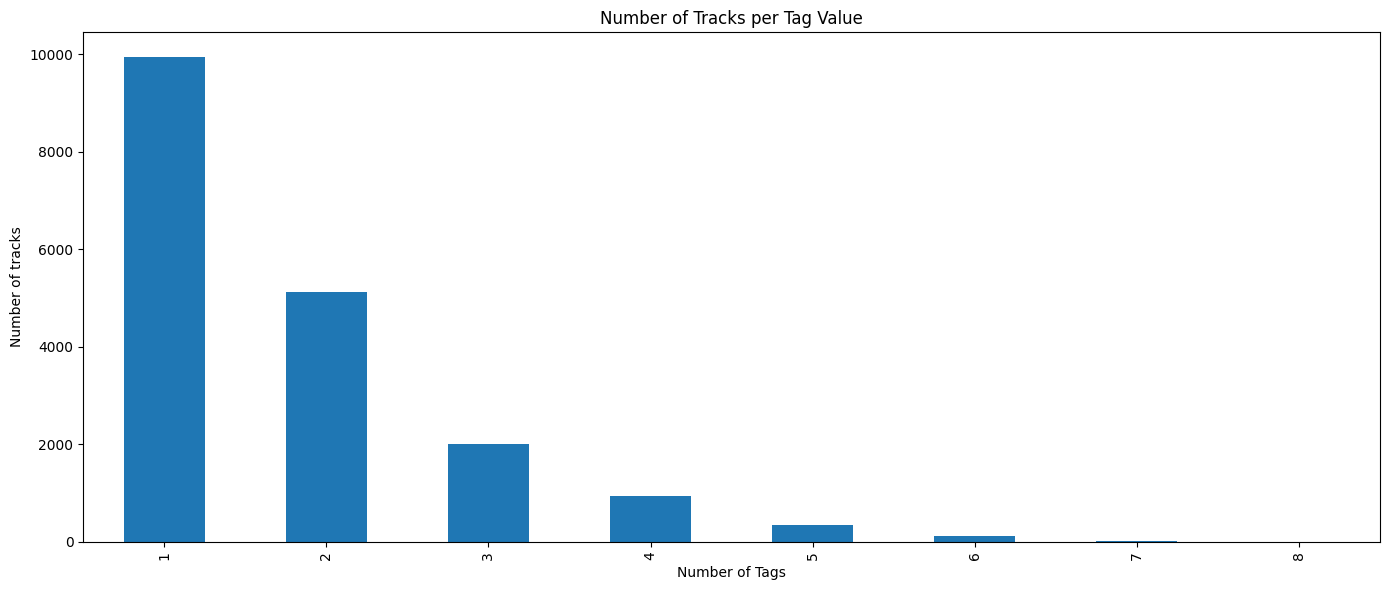

In [104]:
df['NUM_TAGS_PER_TRACK'] = df['TAGS_MOOD'].apply(len)
plt.figure(figsize=(14,6))
df['NUM_TAGS_PER_TRACK'].value_counts().plot(kind='bar')
plt.title("Number of Tracks per Tag Value")
plt.ylabel("Number of tracks")
plt.xlabel("Number of Tags")
plt.tight_layout()
plt.xticks()
plt.show()

In [ ]:
# DF_MERGED = Merging the mood/theme with the instruments 
rows_inst = []
with open('../data/metadata/autotagging_instrument.tsv') as f:
    next(f)
    for line in f:
        parts = line.rstrip('\n').split('\t')
        rows_inst.append({
            'TRACK_ID': parts[0],
            'TAGS_INSTRUMENT': parts[5:]
        })

df_inst = pd.DataFrame(rows_inst)


df_merged = df.merge(df_inst, on='TRACK_ID', how='left')
df_merged.head()


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD,TAGS_INSTRUMENT
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[mood/theme---background],[instrument---synthesizer]
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[mood/theme---background],[instrument---synthesizer]
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[mood/theme---background],[instrument---synthesizer]
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film],NaN
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic],NaN


In [88]:
# Tags with Instrument Tags vs Total Tracks
        # Trying to see if we can add the instruments in the autotagging_instrument.tsv alognside our moods to get bettter/more data
print(f"Total tracks: {len(df_merged)}")
print(f"Tracks with instrument tags: {df_merged['TAGS_INSTRUMENT'].notna().sum()}")
print(f"Tracks without instrument tags: {df_merged['TAGS_INSTRUMENT'].isna().sum()}")
print(f"Coverage: {df_merged['TAGS_INSTRUMENT'].notna().mean()*100:.1f}%")

Total tracks: 18486
Tracks with instrument tags: 10594
Tracks without instrument tags: 7892
Coverage: 57.3%


In [81]:
from collections import Counter

# counting mood distribution before
all_tags = [tag for tags in df_merged['TAGS_MOOD'] for tag in tags]
mood_counts = pd.Series(Counter(all_tags)).sort_values(ascending=False)


# counting mood distribution after removing all songs with NaN for the instrument tags
df_filtered = df_merged[df_merged['TAGS_INSTRUMENT'].notna()].reset_index(drop=True)
all_tags_filtered = [tag for tags in df_filtered['TAGS_MOOD'] for tag in tags]
mood_counts_filtered = pd.Series(Counter(all_tags_filtered)).sort_values(ascending=False)

comparison = pd.DataFrame({
    'before': mood_counts,
    'after': mood_counts_filtered
}).fillna(0)

comparison['ratio'] = comparison['after'] / comparison['before']
print(comparison['ratio'].describe())
print(comparison.sort_values('ratio').head(10))



count    59.000000
mean      0.536442
std       0.129647
min       0.154348
25%       0.458489
50%       0.536512
75%       0.627641
max       0.804301
Name: ratio, dtype: float64
                           before  after     ratio
mood/theme---ambiental        460     71  0.154348
mood/theme---heavy            156     43  0.275641
mood/theme---children         456    146  0.320175
mood/theme---corporate        609    209  0.343186
mood/theme---horror           158     57  0.360759
mood/theme---motivational     635    239  0.376378
mood/theme---inspiring        877    362  0.412771
mood/theme---cool             251    104  0.414343
mood/theme---trailer          270    114  0.422222
mood/theme---party            266    113  0.424812
